# Apr 23 LS vs UV Sigma/Tau Identity Grid

This notebook loads `apr23_1148am_6159c97_chisq.h5` and compares the newly added LS fields against UV DRW fields using `plot_sigma_tau_identity_grid`.


In [27]:
%matplotlib inline

%load_ext autoreload
%autoreload 2
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from qvc.hubble.hubble_utils import load_agn_data
from qvc.light_curve.plotting_appendix import plot_sigma_tau_identity_grid


In [20]:
H5_PATH = Path('../results/data/apr23_1148am_6159c97_chisq.h5')
PLOT_PATH = Path('../plots/hubble/diagnostics/apr23_sigma_tau_ls_vs_uv_identity_grid.pdf')

required_columns = [
    'log_sigma_uv',
    'log_sigma_ls',
    'log_tau_uv_rf',
    'log_tau_ls',
    'log_sigma_uv_err',
    'log_sigma_ls_err',
    'log_tau_uv_rf_err',
    'log_tau_ls_err',
]

SPECTRA_FIT_CSV = ['../results/data/jaxqsofit_apr20c_chisq20_apr18h_all.csv']

df_agn, df_agn_all = load_agn_data(
    str(H5_PATH),
    spectra_fit_csv=SPECTRA_FIT_CSV,
    apply_cut=True,
    only_load=False,
)

for col in required_columns:
    if col in df_agn_all.columns:
        df_agn_all[col] = pd.to_numeric(df_agn_all[col], errors='coerce')
    if col in df_agn.columns:
        df_agn[col] = pd.to_numeric(df_agn[col], errors='coerce')

# Keep original combined identity-grid behavior driven by pre-cut rows.
df = df_agn_all

mask_finite_xy = np.isfinite(df['log_sigma_uv']) & np.isfinite(df['log_sigma_ls'])
mask_finite_xy &= np.isfinite(df['log_tau_uv_rf']) & np.isfinite(df['log_tau_ls'])
plot_df = df.loc[mask_finite_xy].copy()

# Explicit pre/post frames from load_agn_data outputs.
pre_df = df_agn_all.copy()
post_df = df_agn.copy()

print(f'Loaded pre-cut rows (df_agn_all): {len(df_agn_all):,}')
print(f'Loaded post-cut rows (df_agn): {len(df_agn):,}')
print(f'Rows with finite sigma/tau x/y fields (combined plot input): {len(plot_df):,}')


Applied column compatibility shim: log_mbh->LOGMBH, log_mbh_err->LOGMBH_ERR
Number of quasars loaded: 23456
Populating spectra fit data from: ['/home/dutra/dev/qvc2/results/data/jaxqsofit_apr20c_chisq20_apr18h_all.csv']
Loading spectra fit CSV (1/1): /home/dutra/dev/qvc2/results/data/jaxqsofit_apr20c_chisq20_apr18h_all.csv
Length of merged DataFrame: 23456
Using f_host_2500_psf from PSF posterior reconstruction as the primary host fraction; completeness reads f_host_2500_psf explicitly.
Filled 748 NaN f_host_2500 values with 0.0
Computed light_curve_n_points from: variability_n_points_g, variability_n_points_i, variability_n_points_r excluding bands: u
Suberlak-style fit [precut M_2500] for sigma_uv using M_2500 at lambda_RF=2500 A (B fixed=-0.479, N=23330, chi2_red=0.916): A=-0.8998±0.0017, C=0.0807±0.0010 (Suberlak 0.1180), D=0.0756±0.0030 (Suberlak 0.1180), sigma_int=0.0762±0.0015 dex
Suberlak-style fit [precut M_2500] for tau_uv_rf using M_2500 at lambda_RF=2500 A (B fixed=0.170, N

/home/dutra/.conda/envs/jaxcpu4/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


Number of quasars with 0 < z <= 1.0: 1651
Number of dropped quasars with 0 < z <= 1.0: 3358
Number of quasars with z > 3: 200

Total number of objects removed by all cuts: 14835
Final number of quasars: 8621
Suberlak-style fit [postcut M_2500] for sigma_uv using M_2500 at lambda_RF=2500 A (B fixed=-0.479, N=8596, chi2_red=0.905): A=-0.9310±0.0023, C=0.0819±0.0016 (Suberlak 0.1180), D=0.0792±0.0046 (Suberlak 0.1180), sigma_int=0.0108±0.0071 dex
Suberlak-style fit [postcut M_2500] for tau_uv_rf using M_2500 at lambda_RF=2500 A (B fixed=0.170, N=8596, chi2_red=0.902): A=2.5715±0.0058, C=-0.0207±0.0034 (Suberlak 0.0350), D=0.0902±0.0095 (Suberlak 0.1410), sigma_int=0.2032±0.0037 dex
Suberlak-style fit [postcut M_i_Wu_z2] for sigma_uv using M_i_Wu_z2 at lambda_RF=2500 A (B fixed=-0.479, N=8554, chi2_red=0.896): A=-0.9345±0.0027, C=0.0832±0.0016 (Suberlak 0.1180), D=0.0914±0.0050 (Suberlak 0.1180), sigma_int=0.0076±0.0060 dex
Suberlak-style fit [postcut M_i_Wu_z2] for tau_uv_rf using M_i_Wu_

In [21]:
summary_cols = [
    'log_sigma_uv',
    'log_sigma_ls',
    'log_tau_uv_rf',
    'log_tau_ls',
    'log_sigma_uv_err',
    'log_sigma_ls_err',
    'log_tau_uv_rf_err',
    'log_tau_ls_err',
]

diag = pd.DataFrame({
    'finite_count': [int(np.isfinite(plot_df[c]).sum()) for c in summary_cols],
    'nan_count': [int(plot_df[c].isna().sum()) for c in summary_cols],
}, index=summary_cols)
diag


,finite_count,nan_count
log_sigma_uv,23456,0
log_sigma_ls,23456,0
log_tau_uv_rf,23456,0
log_tau_ls,23456,0
log_sigma_uv_err,23456,0
log_sigma_ls_err,23456,0
log_tau_uv_rf_err,23456,0
log_tau_ls_err,23456,0


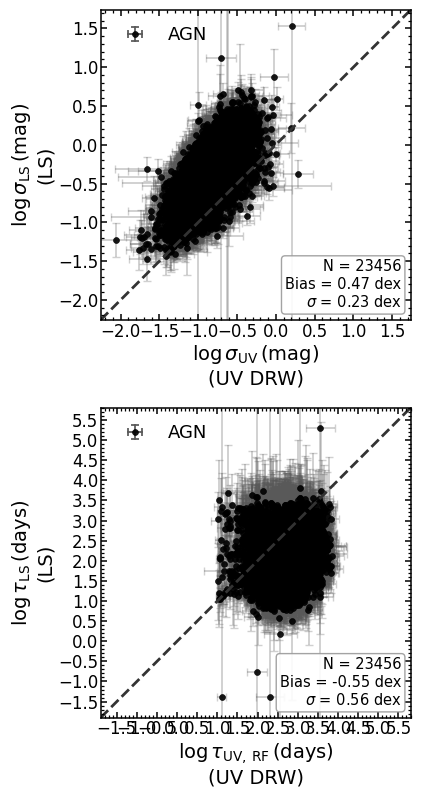

Wrote plot to: /home/dutra/dev/qvc2/plots/hubble/diagnostics/apr23_sigma_tau_ls_vs_uv_identity_grid.pdf


In [22]:
sigma_keys = {
    'x': 'log_sigma_uv',
    'y': 'log_sigma_ls',
    'xerr': 'log_sigma_uv_err',
    'yerr': 'log_sigma_ls_err',
    'xlabel': r'$\log\!\,\sigma_{\mathrm{UV}}\,(\mathrm{mag})$' '\n(UV DRW)',
    'ylabel': r'$\log\!\,\sigma_{\mathrm{LS}}\,(\mathrm{mag})$' '\n(LS)',
}

tau_keys = {
    'x': 'log_tau_uv_rf',
    'y': 'log_tau_ls',
    'xerr': 'log_tau_uv_rf_err',
    'yerr': 'log_tau_ls_err',
    'xlabel': r'$\log\!\,\tau_{\mathrm{UV},\,\mathrm{RF}}\,(\mathrm{days})$' '\n(UV DRW)',
    'ylabel': r'$\log\!\,\tau_{\mathrm{LS}}\,(\mathrm{days})$' '\n(LS)',
}

PLOT_PATH.parent.mkdir(parents=True, exist_ok=True)

fig = plot_sigma_tau_identity_grid(
    plot_df,
    sigma_keys,
    tau_keys,
    bands=('uv',),
    figsize=(4.8, 7.8),
    show=True,
    output_path=str(PLOT_PATH),
)

print(f'Wrote plot to: {PLOT_PATH.resolve()}')
plt.close(fig)


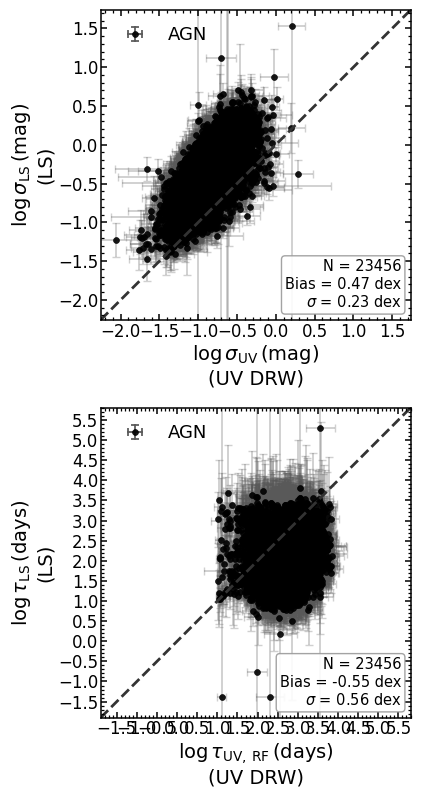

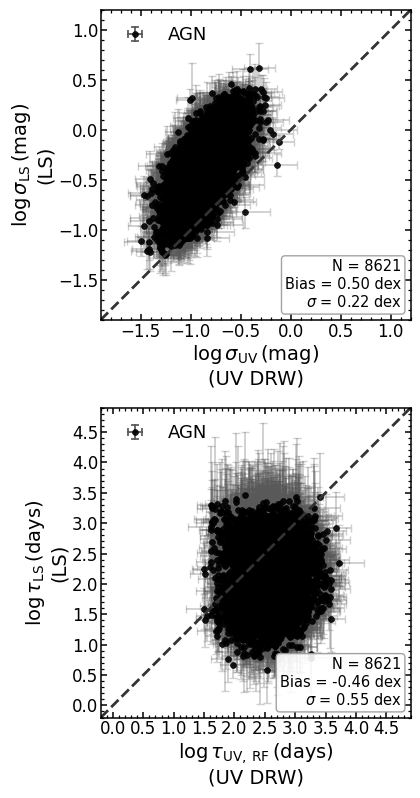

Pre-cut identity grid written to: /home/dutra/dev/qvc2/plots/hubble/diagnostics/apr23_sigma_tau_ls_identity_precut.pdf
  sigma finite rows used: 23,456
  tau finite rows used: 23,456
Post-cut identity grid written to: /home/dutra/dev/qvc2/plots/hubble/diagnostics/apr23_sigma_tau_ls_identity_postcut.pdf
  sigma finite rows used: 8,621
  tau finite rows used: 8,621


In [31]:
PRE_PLOT_PATH = Path('../plots/hubble/diagnostics/apr23_sigma_tau_ls_identity_precut.pdf')
POST_PLOT_PATH = Path('../plots/hubble/diagnostics/apr23_sigma_tau_ls_identity_postcut.pdf')

assert len(post_df) < len(pre_df), 'Post-cut should be smaller than pre-cut.'


def _metric_finite_subset(frame, keys):
    finite = np.isfinite(frame[keys['x']]) & np.isfinite(frame[keys['y']])
    xerr_key = keys.get('xerr')
    yerr_key = keys.get('yerr')
    if xerr_key is not None and xerr_key in frame.columns:
        finite &= np.isfinite(frame[xerr_key])
    if yerr_key is not None and yerr_key in frame.columns:
        finite &= np.isfinite(frame[yerr_key])
    return frame.loc[finite].copy()


pre_sigma = _metric_finite_subset(pre_df, sigma_keys)
pre_tau = _metric_finite_subset(pre_df, tau_keys)
post_sigma = _metric_finite_subset(post_df, sigma_keys)
post_tau = _metric_finite_subset(post_df, tau_keys)

PRE_PLOT_PATH.parent.mkdir(parents=True, exist_ok=True)

fig_pre = plot_sigma_tau_identity_grid(
    pre_df,
    sigma_keys,
    tau_keys,
    bands=('uv',),
    figsize=(4.8, 7.8),
    show=True,
    output_path=str(PRE_PLOT_PATH),
)
plt.close(fig_pre)

fig_post = plot_sigma_tau_identity_grid(
    post_df,
    sigma_keys,
    tau_keys,
    bands=('uv',),
    figsize=(4.8, 7.8),
    show=True,
    output_path=str(POST_PLOT_PATH),
    sigma_limits=(-1.9, 1.2),
    tau_limits=(-0.2, 4.9)
)
plt.close(fig_post)

print(f'Pre-cut identity grid written to: {PRE_PLOT_PATH.resolve()}')
print(f'  sigma finite rows used: {len(pre_sigma):,}')
print(f'  tau finite rows used: {len(pre_tau):,}')
print(f'Post-cut identity grid written to: {POST_PLOT_PATH.resolve()}')
print(f'  sigma finite rows used: {len(post_sigma):,}')
print(f'  tau finite rows used: {len(post_tau):,}')
